In [1]:
# Install (if needed)
!pip install xgboost lightgbm catboost shap -q

# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("2023_2024weather_daily.csv")

target = "Aflatoxin"
numeric_features = [
    "temperature",
    "RH",
    "NDVI",
    "total_precipitation",
    "days_from_planting",
    "wind_u",
    "wind_v",
    "pressure",
    "latitude",
    "longitude"
]
categorical_features = ["Location"]
features = numeric_features + categorical_features

df_model = df[features + [target]].dropna().copy()
df_model["contamination"] = (df_model["Aflatoxin"] > 0).astype(int)

print(df_model.shape)
print(df_model["contamination"].value_counts())
print(df_model["contamination"].value_counts(normalize=True))

(51129, 13)
contamination
0    46547
1     4582
Name: count, dtype: int64
contamination
0    0.910384
1    0.089616
Name: proportion, dtype: float64


In [3]:
X = df_model[features]
y = df_model["contamination"]
groups = df.loc[df_model.index, "Location"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Classification model
clf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"   # IMPORTANT for imbalance
    ))
])

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

gkf = GroupKFold(n_splits=5)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf_model.fit(X_train, y_train)
    y_pred = clf_model.predict(X_test)
    y_prob = clf_model.predict_proba(X_test)[:, 1]

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))
    roc_auc_scores.append(roc_auc_score(y_test, y_prob))

    print(f"Fold {fold}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1:", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("-" * 30)

print("Average Accuracy:", np.mean(accuracy_scores))
print("Average Precision:", np.mean(precision_scores))
print("Average Recall:", np.mean(recall_scores))
print("Average F1:", np.mean(f1_scores))
print("Average ROC-AUC:", np.mean(roc_auc_scores))

Fold 1
Accuracy: 0.8378176382660688
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.53008546516647
------------------------------
Fold 2
Accuracy: 0.8434579439252337
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.5176541117129037
------------------------------
Fold 3
Accuracy: 0.6795585412667946
Precision: 0.031889290012033694
Recall: 0.4669603524229075
F1: 0.05970149253731343
ROC-AUC: 0.6601185230772955
------------------------------
Fold 4
Accuracy: 0.6392215568862275
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.17725699905630704
------------------------------
Fold 5
Accuracy: 0.9456398640996603
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.5349194173636198
------------------------------
Average Accuracy: 0.7891391088887969
Average Precision: 0.006377858002406739
Average Recall: 0.09339207048458151
Average F1: 0.011940298507462687
Average ROC-AUC: 0.4840069032753192


adjust prediction threshold

In [5]:
threshold = 0.2  # try lower threshold

precision_list = []
recall_list = []
f1_list = []

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf_model.fit(X_train, y_train)
    y_prob = clf_model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob > threshold).astype(int)

    precision_list.append(precision_score(y_test, y_pred, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred, zero_division=0))

print("Threshold:", threshold)
print("Precision:", np.mean(precision_list))
print("Recall:", np.mean(recall_list))
print("F1:", np.mean(f1_list))

Threshold: 0.2
Precision: 0.0834373289514874
Recall: 0.7335255540479421
F1: 0.14361172406492795


Regression Stage

In [6]:
df_nonzero = df_model[df_model["Aflatoxin"] > 0].copy()

print(df_nonzero.shape)

(4582, 13)


In [7]:
X_reg = df_nonzero[features]
y_reg = df_nonzero["Aflatoxin"]
groups_reg = df.loc[df_nonzero.index, "Location"]

print("X_reg shape:", X_reg.shape)
print("y_reg summary:")
print(y_reg.describe())

X_reg shape: (4582, 11)
y_reg summary:
count    4582.000000
mean        5.862200
std        10.074217
min         0.460000
25%         1.400000
50%         2.700000
75%         3.700000
max        35.000000
Name: Aflatoxin, dtype: float64


In [8]:
from sklearn.ensemble import RandomForestRegressor

In [9]:
# Preprocessing (same as before)
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Regression model
reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

evaluate the regression model (grouped CV)

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [11]:
rmse_scores = []
mae_scores = []
r2_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_reg, y_reg, groups_reg), start=1):
    X_train, X_test = X_reg.iloc[train_idx], X_reg.iloc[test_idx]
    y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"Fold {fold}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R²:", r2)
    print("-" * 30)

print("Average RMSE:", np.mean(rmse_scores))
print("Average MAE:", np.mean(mae_scores))
print("Average R²:", np.mean(r2_scores))

Fold 1
RMSE: 9.55416974459801
MAE: 9.489932643654763
R²: -76.97813486612633
------------------------------
Fold 2
RMSE: 0.9604884425193371
MAE: 0.8345891772838047
R²: -3.0452338289495726
------------------------------
Fold 3
RMSE: 3.3099485049858277
MAE: 2.654838658476383
R²: -1.7389397764144818
------------------------------
Fold 4
RMSE: 1.4258125272717794
MAE: 1.4142891145839442
R²: -0.21917961154154275
------------------------------
Fold 5
RMSE: 25.92887944593095
MAE: 21.597564633527558
R²: -1.764689075379592
------------------------------
Average RMSE: 8.23585973306118
Average MAE: 7.198242845505291
Average R²: -16.749235431682305


SHAP

In [12]:
import shap

In [13]:
# Fit model on full data (classification)
clf_model.fit(X, y)

# Get processed feature matrix
X_processed = clf_model.named_steps["preprocessor"].transform(X)

# Get model
model = clf_model.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_processed)

In [14]:
feature_names = clf_model.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))
print(feature_names)

22
['num__temperature' 'num__RH' 'num__NDVI' 'num__total_precipitation'
 'num__days_from_planting' 'num__wind_u' 'num__wind_v' 'num__pressure'
 'num__latitude' 'num__longitude' 'cat__Location_ACRE'
 'cat__Location_Albany' 'cat__Location_Arlington' 'cat__Location_Columbia'
 'cat__Location_KY-2' 'cat__Location_KY-3' 'cat__Location_Lancaster'
 'cat__Location_MRRS' 'cat__Location_Michigan' 'cat__Location_NWRF'
 'cat__Location_PPAC' 'cat__Location_SERF']


In [15]:
print(type(shap_values))

if isinstance(shap_values, list):
    for i, sv in enumerate(shap_values):
        print(f"Class {i} shap shape:", np.array(sv).shape)
else:
    print("shap_values shape:", np.array(shap_values).shape)

print("X_processed shape:", X_processed.shape)

<class 'numpy.ndarray'>
shap_values shape: (51129, 22, 2)
X_processed shape: (51129, 22)


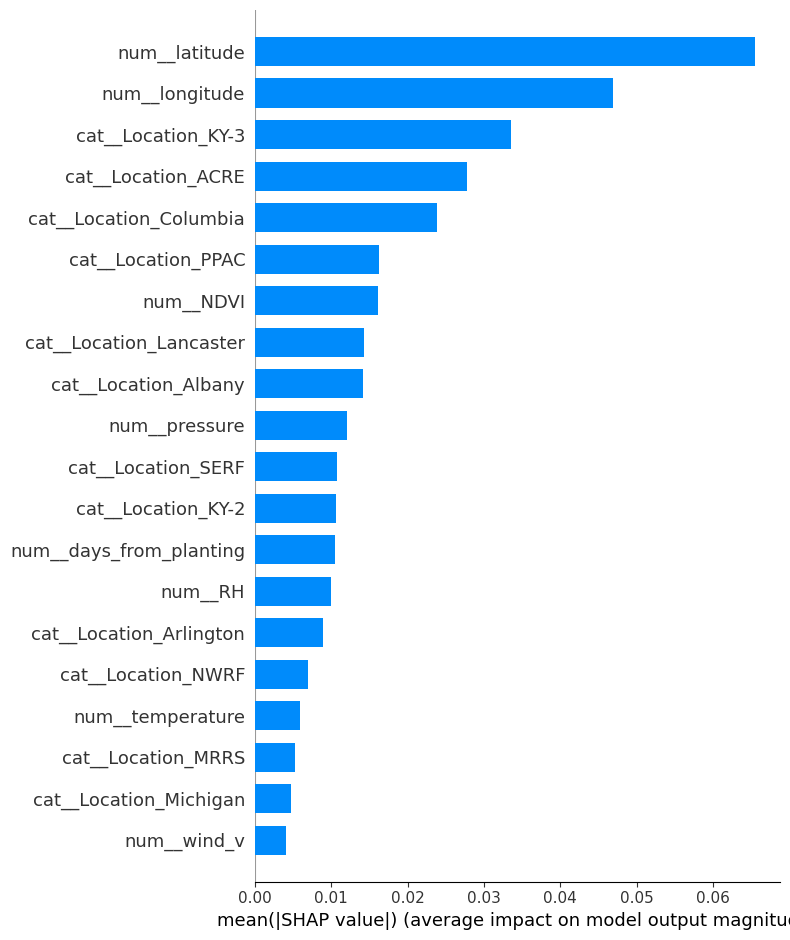

In [16]:
shap_class1 = shap_values[:, :, 1]

shap.summary_plot(
    shap_class1,
    X_processed,
    feature_names=feature_names,
    plot_type="bar"
)

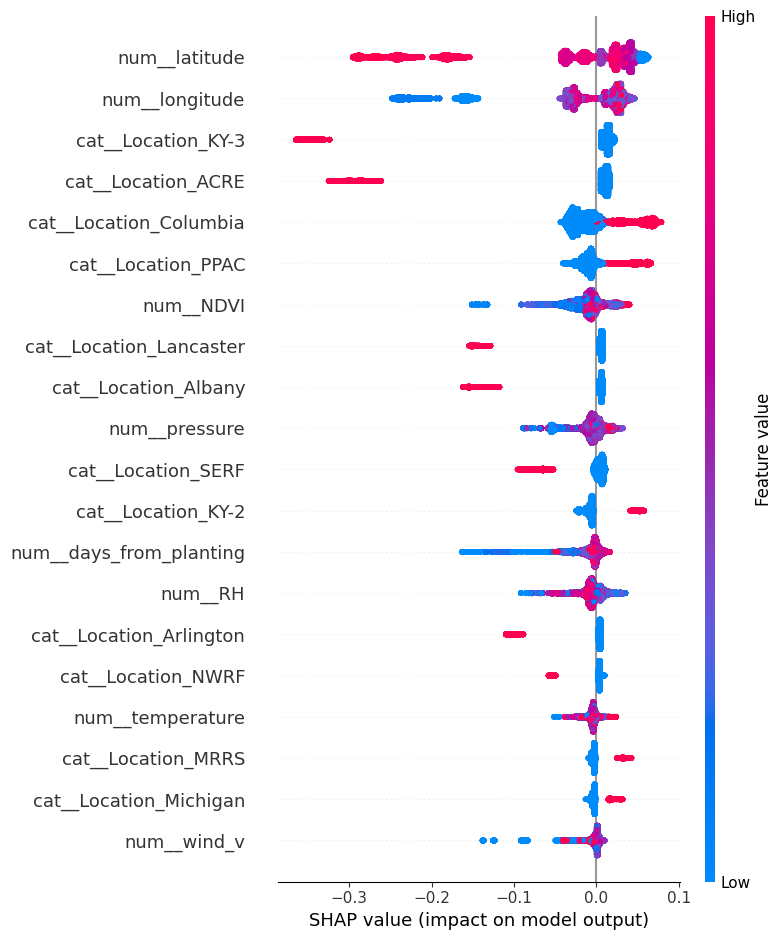

In [17]:
shap.summary_plot(
    shap_class1,
    X_processed,
    feature_names=feature_names
)

Visualization for Presentation

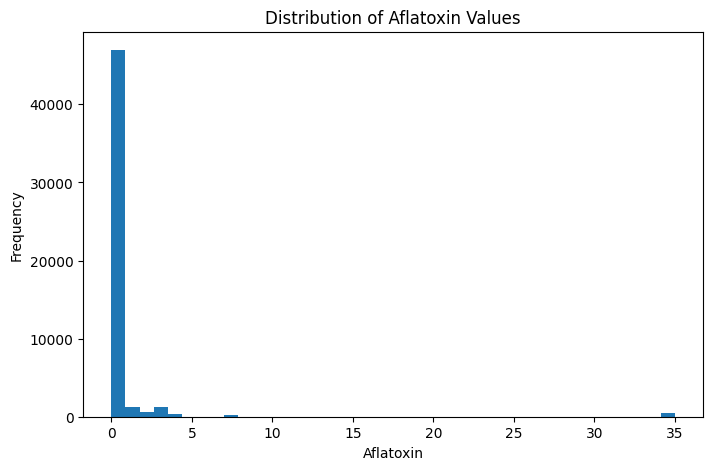

Percent zero: 91.03835396741576
Percent non-zero: 8.961646032584248


In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_model["Aflatoxin"], bins=40)
plt.xlabel("Aflatoxin")
plt.ylabel("Frequency")
plt.title("Distribution of Aflatoxin Values")
plt.show()

print("Percent zero:", (df_model["Aflatoxin"] == 0).mean() * 100)
print("Percent non-zero:", (df_model["Aflatoxin"] > 0).mean() * 100)

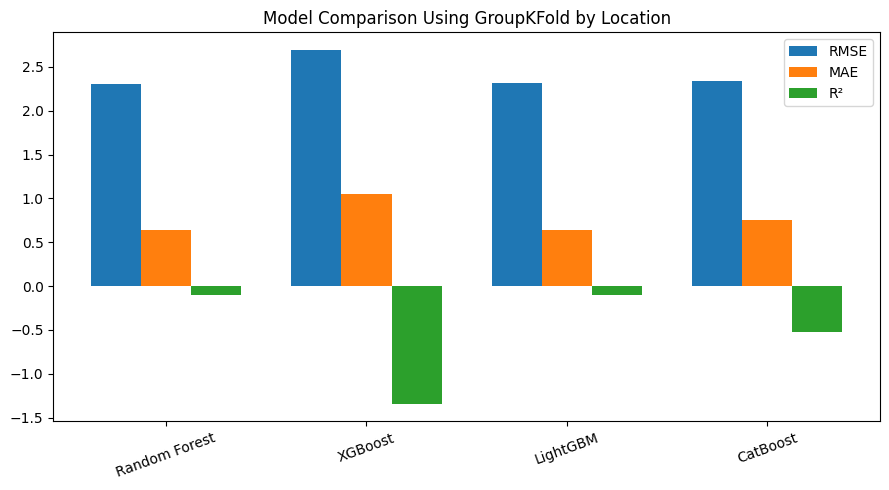

           Model      RMSE       MAE        R2
0  Random Forest  2.303069  0.641587 -0.099514
1        XGBoost  2.691215  1.050752 -1.340425
2       LightGBM  2.311390  0.639841 -0.101013
3       CatBoost  2.334766  0.757817 -0.520150


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "RMSE": [2.303069, 2.691215, 2.311390, 2.334766],
    "MAE":  [0.641587, 1.050752, 0.639841, 0.757817],
    "R2":   [-0.099514, -1.340425, -0.101013, -0.520150]
})

fig, ax = plt.subplots(figsize=(9,5))
x = range(len(results_df))
width = 0.25

ax.bar([i - width for i in x], results_df["RMSE"], width=width, label="RMSE")
ax.bar(x, results_df["MAE"], width=width, label="MAE")
ax.bar([i + width for i in x], results_df["R2"], width=width, label="R²")

ax.set_xticks(list(x))
ax.set_xticklabels(results_df["Model"], rotation=20)
ax.set_title("Model Comparison Using GroupKFold by Location")
ax.legend()
plt.tight_layout()
plt.show()

print(results_df)

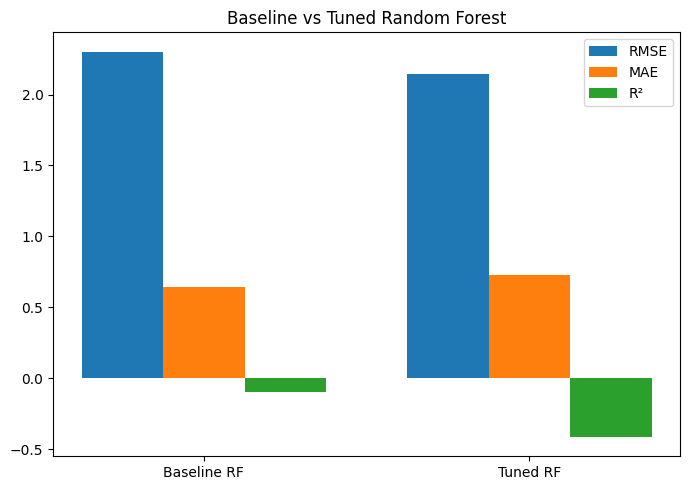

       Version      RMSE       MAE        R2
0  Baseline RF  2.303069  0.641587 -0.099514
1     Tuned RF  2.141733  0.725157 -0.415098


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

rf_compare = pd.DataFrame({
    "Version": ["Baseline RF", "Tuned RF"],
    "RMSE": [2.303069, 2.141733],
    "MAE": [0.641587, 0.725157],
    "R2": [-0.099514, -0.415098]
})

fig, ax = plt.subplots(figsize=(7,5))
x = range(len(rf_compare))
width = 0.25

ax.bar([i - width for i in x], rf_compare["RMSE"], width=width, label="RMSE")
ax.bar(x, rf_compare["MAE"], width=width, label="MAE")
ax.bar([i + width for i in x], rf_compare["R2"], width=width, label="R²")

ax.set_xticks(list(x))
ax.set_xticklabels(rf_compare["Version"])
ax.set_title("Baseline vs Tuned Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

print(rf_compare)

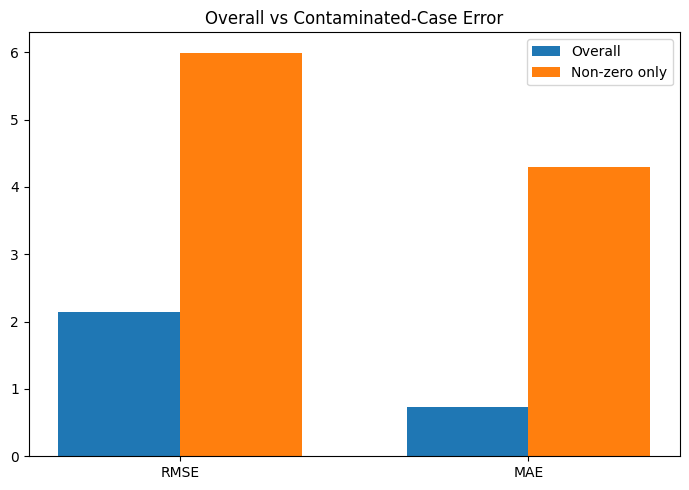

  Metric   Overall  Non-zero only
0   RMSE  2.141733       5.996987
1    MAE  0.725157       4.289673


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

eval_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE"],
    "Overall": [2.141733, 0.725157],
    "Non-zero only": [5.996987, 4.289673]
})

fig, ax = plt.subplots(figsize=(7,5))
x = range(len(eval_df))
width = 0.35

ax.bar([i - width/2 for i in x], eval_df["Overall"], width=width, label="Overall")
ax.bar([i + width/2 for i in x], eval_df["Non-zero only"], width=width, label="Non-zero only")

ax.set_xticks(list(x))
ax.set_xticklabels(eval_df["Metric"])
ax.set_title("Overall vs Contaminated-Case Error")
ax.legend()
plt.tight_layout()
plt.show()

print(eval_df)

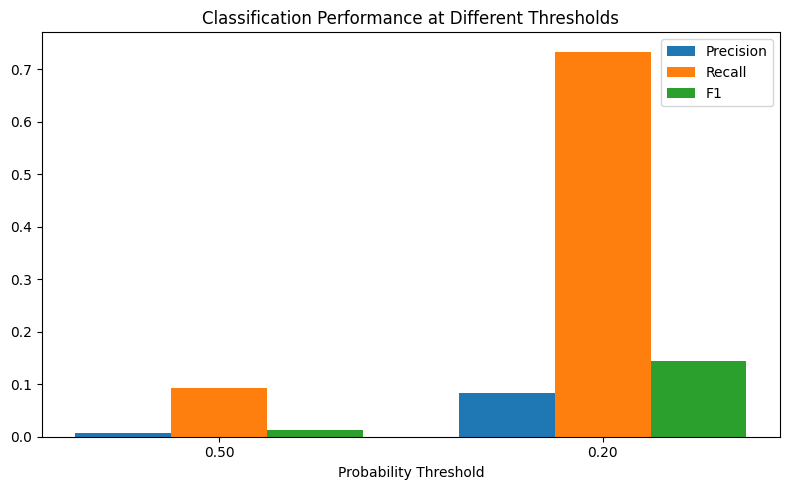

  Threshold  Precision    Recall        F1
0      0.50   0.006378  0.093392  0.011940
1      0.20   0.083437  0.733526  0.143612


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

threshold_df = pd.DataFrame({
    "Threshold": ["0.50", "0.20"],
    "Precision": [0.006378, 0.083437],
    "Recall": [0.093392, 0.733526],
    "F1": [0.011940, 0.143612]
})

fig, ax = plt.subplots(figsize=(8,5))
x = range(len(threshold_df))
width = 0.25

ax.bar([i - width for i in x], threshold_df["Precision"], width=width, label="Precision")
ax.bar(x, threshold_df["Recall"], width=width, label="Recall")
ax.bar([i + width for i in x], threshold_df["F1"], width=width, label="F1")

ax.set_xticks(list(x))
ax.set_xticklabels(threshold_df["Threshold"])
ax.set_title("Classification Performance at Different Thresholds")
ax.set_xlabel("Probability Threshold")
ax.legend()
plt.tight_layout()
plt.show()

print(threshold_df)

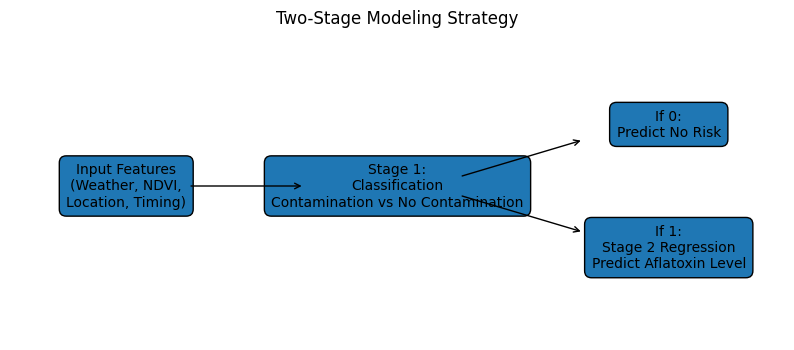

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))
ax.axis("off")

ax.text(0.15, 0.5, "Input Features\n(Weather, NDVI,\nLocation, Timing)",
        ha="center", va="center", bbox=dict(boxstyle="round", pad=0.5))
ax.text(0.5, 0.5, "Stage 1:\nClassification\nContamination vs No Contamination",
        ha="center", va="center", bbox=dict(boxstyle="round", pad=0.5))
ax.text(0.85, 0.7, "If 0:\nPredict No Risk",
        ha="center", va="center", bbox=dict(boxstyle="round", pad=0.5))
ax.text(0.85, 0.3, "If 1:\nStage 2 Regression\nPredict Aflatoxin Level",
        ha="center", va="center", bbox=dict(boxstyle="round", pad=0.5))

ax.annotate("", xy=(0.38, 0.5), xytext=(0.23, 0.5), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.74, 0.65), xytext=(0.58, 0.53), arrowprops=dict(arrowstyle="->"))
ax.annotate("", xy=(0.74, 0.35), xytext=(0.58, 0.47), arrowprops=dict(arrowstyle="->"))

plt.title("Two-Stage Modeling Strategy")
plt.show()

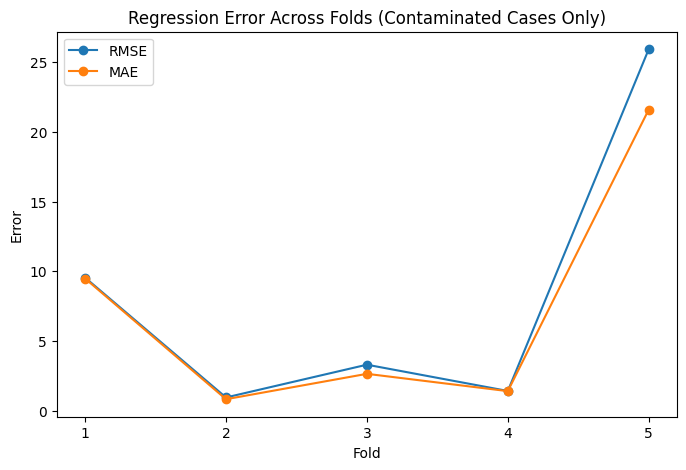

In [24]:
import matplotlib.pyplot as plt

fold_rmse = [9.554170, 0.960488, 3.309949, 1.425813, 25.928879]
fold_mae  = [9.489933, 0.834589, 2.654839, 1.414289, 21.597565]

folds = [1, 2, 3, 4, 5]

plt.figure(figsize=(8,5))
plt.plot(folds, fold_rmse, marker="o", label="RMSE")
plt.plot(folds, fold_mae, marker="o", label="MAE")
plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("Error")
plt.title("Regression Error Across Folds (Contaminated Cases Only)")
plt.legend()
plt.show()

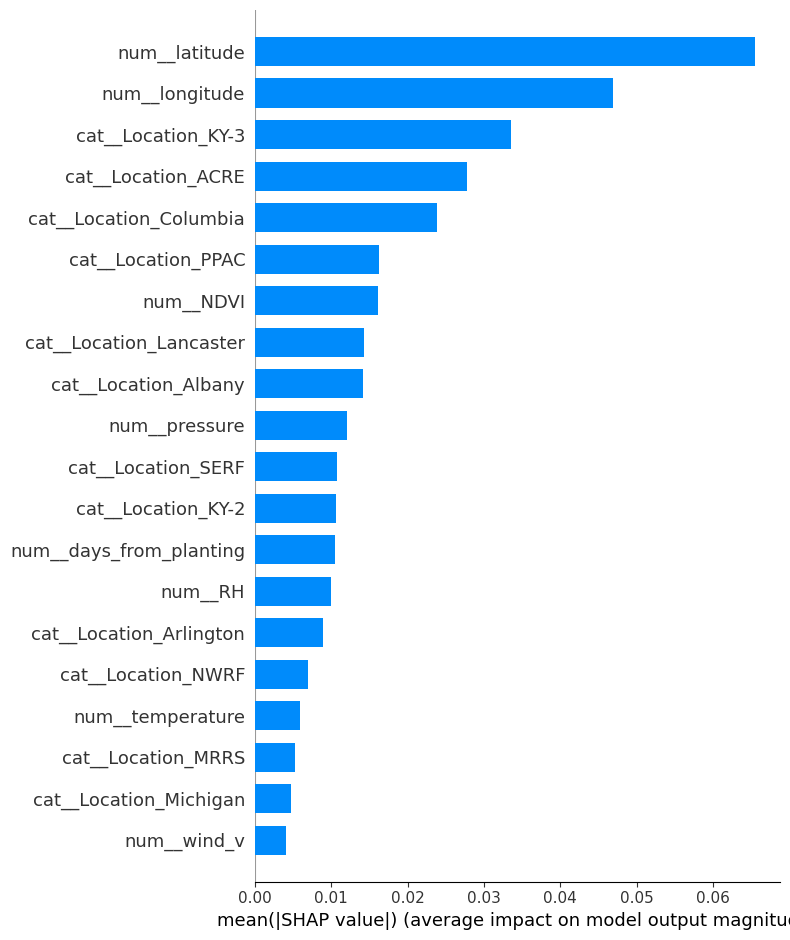

In [25]:
import shap

shap.summary_plot(
    shap_class1,
    X_processed,
    feature_names=feature_names,
    plot_type="bar"
)

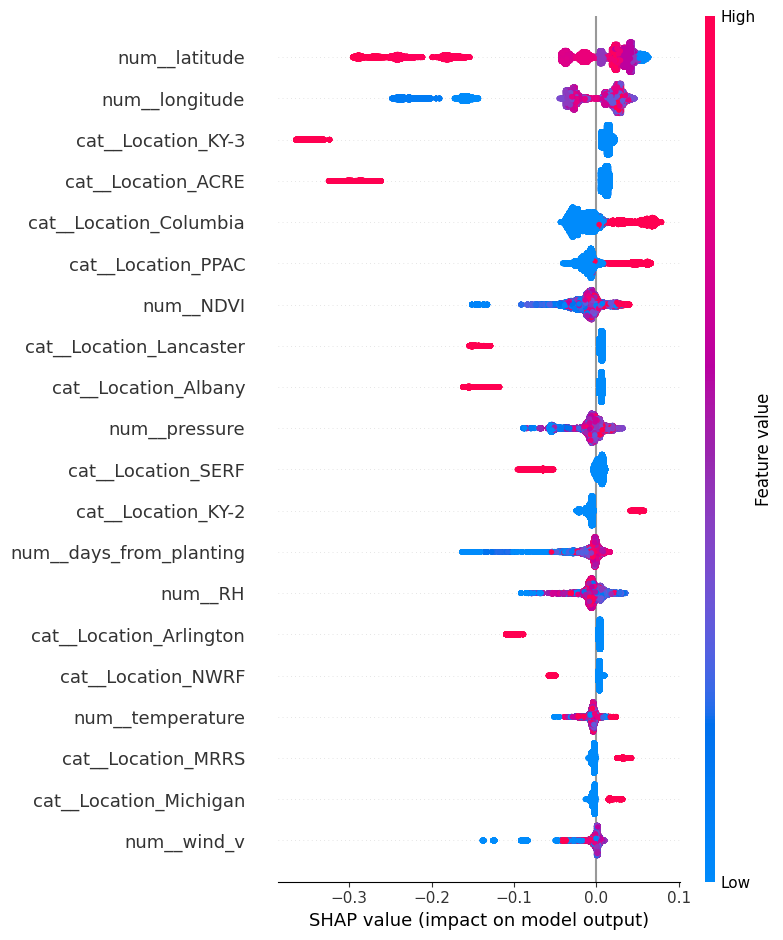

In [26]:
shap.summary_plot(
    shap_class1,
    X_processed,
    feature_names=feature_names
)

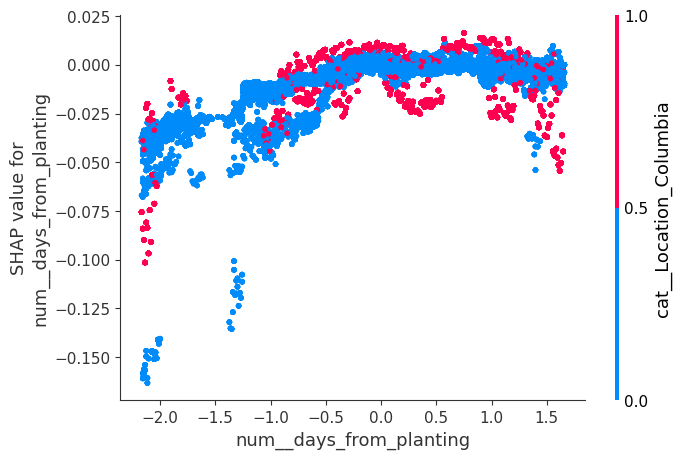

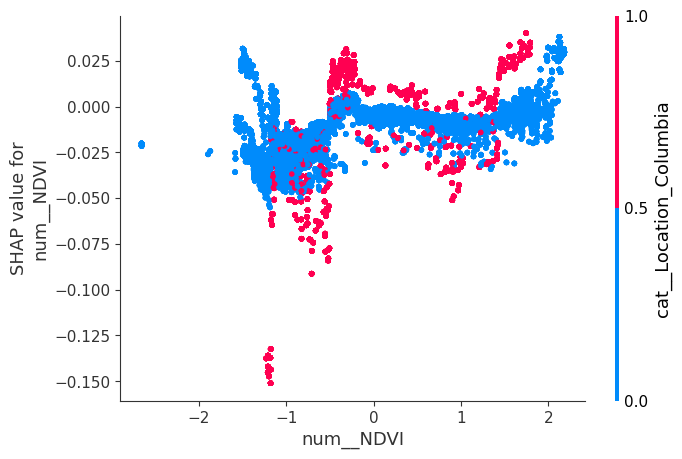

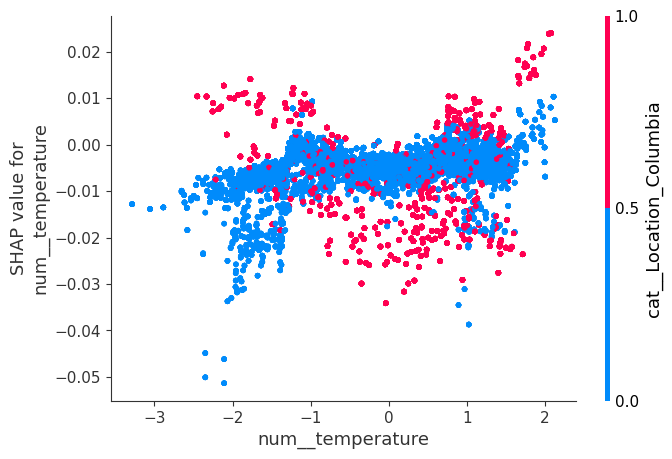

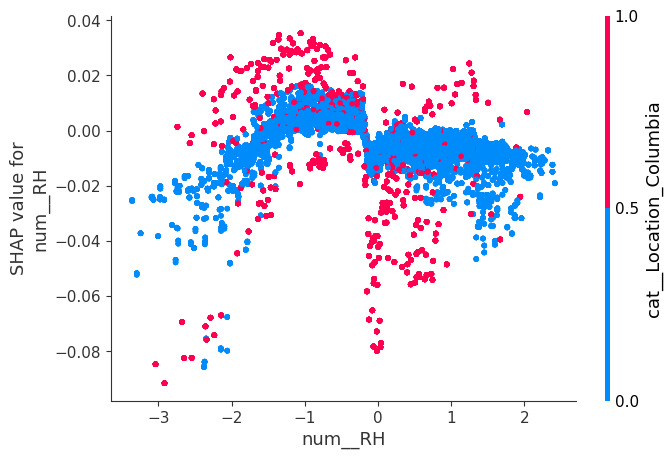

In [27]:
shap.dependence_plot(
    "num__days_from_planting",
    shap_class1,
    X_processed,
    feature_names=feature_names
)

shap.dependence_plot(
    "num__NDVI",
    shap_class1,
    X_processed,
    feature_names=feature_names
)

shap.dependence_plot(
    "num__temperature",
    shap_class1,
    X_processed,
    feature_names=feature_names
)

shap.dependence_plot(
    "num__RH",
    shap_class1,
    X_processed,
    feature_names=feature_names
)

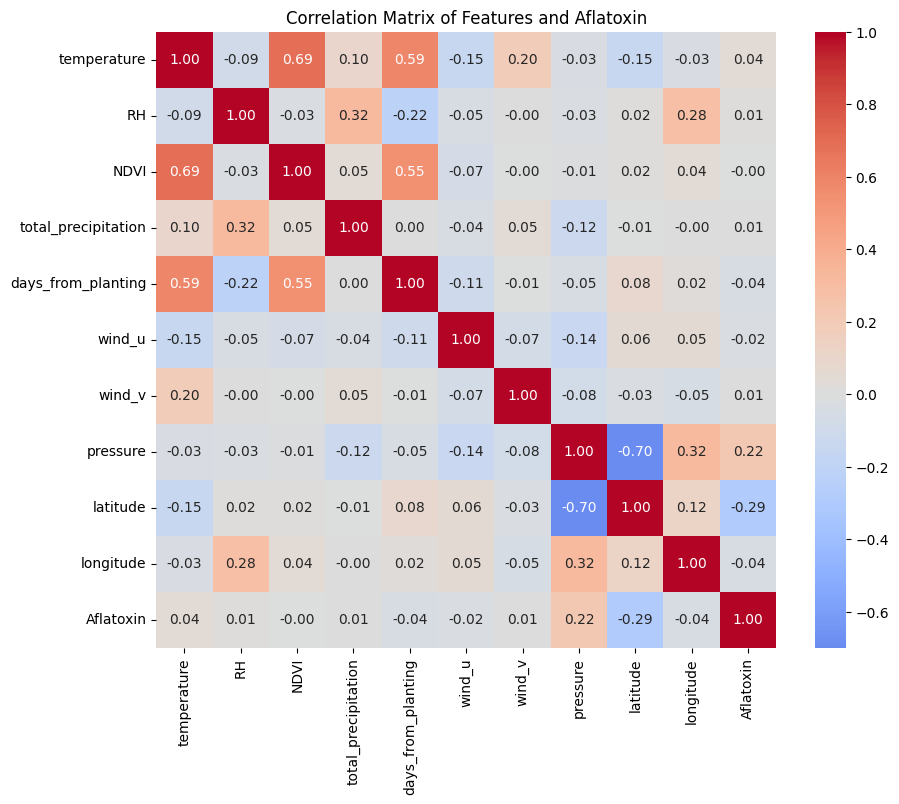

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only numeric features
corr_features = numeric_features + ["Aflatoxin"]

corr_matrix = df_model[corr_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Features and Aflatoxin")
plt.show()

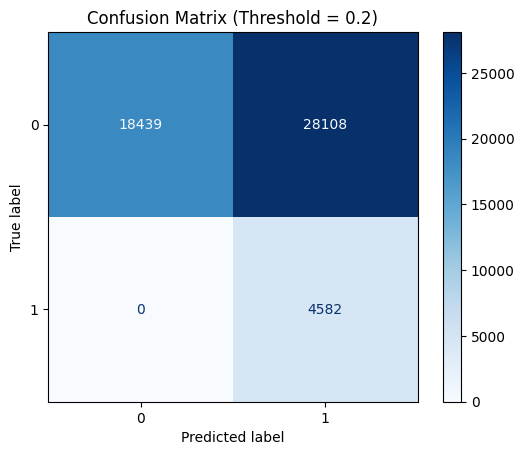

Confusion Matrix:
 [[18439 28108]
 [    0  4582]]


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fit model on ALL data
clf_model.fit(X, y)

# Predictions (use threshold = 0.2 since you improved recall earlier)
y_prob = clf_model.predict_proba(X)[:, 1]
y_pred = (y_prob >= 0.2).astype(int)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix (Threshold = 0.2)")
plt.show()

print("Confusion Matrix:\n", cm)

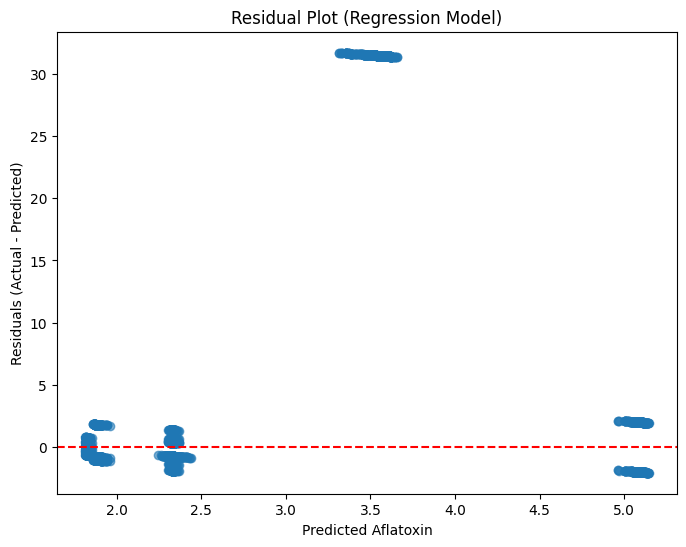

In [30]:
import matplotlib.pyplot as plt

# Predictions from regression model
y_pred = reg_model.predict(X_reg)

# Residuals
residuals = y_reg - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Aflatoxin")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Regression Model)")

plt.show()